# Winograd convolution

So, the english is not very good, I will improve that

In [51]:
import itertools

import sympy as sy
import numpy as np

In [52]:
import fitz
from PIL import Image
from IPython.display import display, YouTubeVideo

In [53]:
doc = fitz.open('/home/tarsio/zotero-lib/AUTH/Blahut/Blahut_2010_Fast algorithms for signal processing.pdf')

In [54]:
def plot_pdf(page, crop_float=None,  dpi=200,):
    """
    (upper, lower)
    crop float value between 0 and 1
    """
    pix = page.get_pixmap(dpi=dpi)
    # mode = "RGBA" if pix.alpha else "RGB"
    mode = "RGB"
    image = Image.frombytes(mode, [pix.width, pix.height], pix.samples)
    if crop_float is None:
        display(image)
    else:
        assert 0 <= crop_float[0] <= 1
        assert 0 <= crop_float[1] <= 1
        # assert 0 <= crop_float[2] <= 1
        # assert 0 <= crop_float[3] <= 1
        left = 0
        upper = int(pix.height * crop_float[0])
        right = pix.width
        lower = int(pix.height * crop_float[1])
        crop = (left, upper, right, lower)
        display(image.crop(crop))

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from Youtube.

In this tutorial I will quote the theoretical first and the example after that for best understanding.

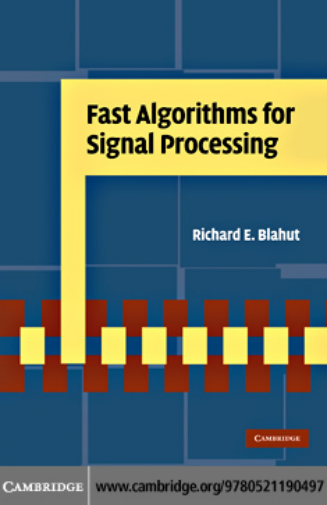

In [55]:
plot_pdf(doc[0], dpi=100)

## Polynomials

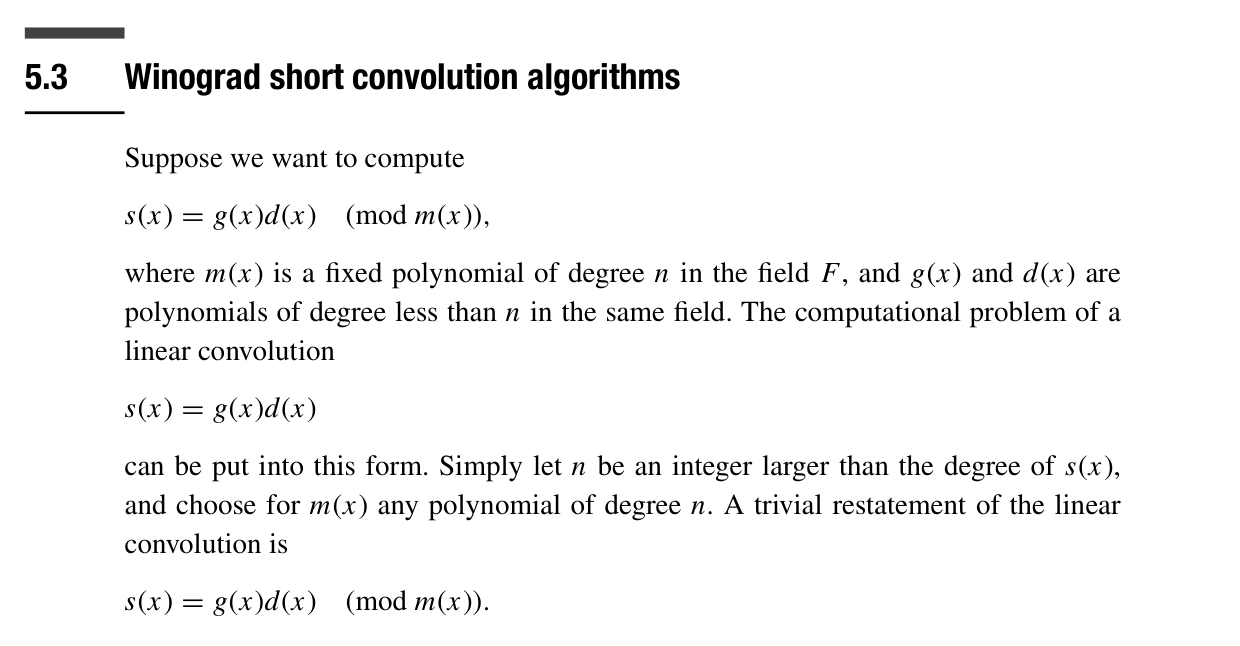

In [56]:
plot_pdf(doc[170], [.55, .89])

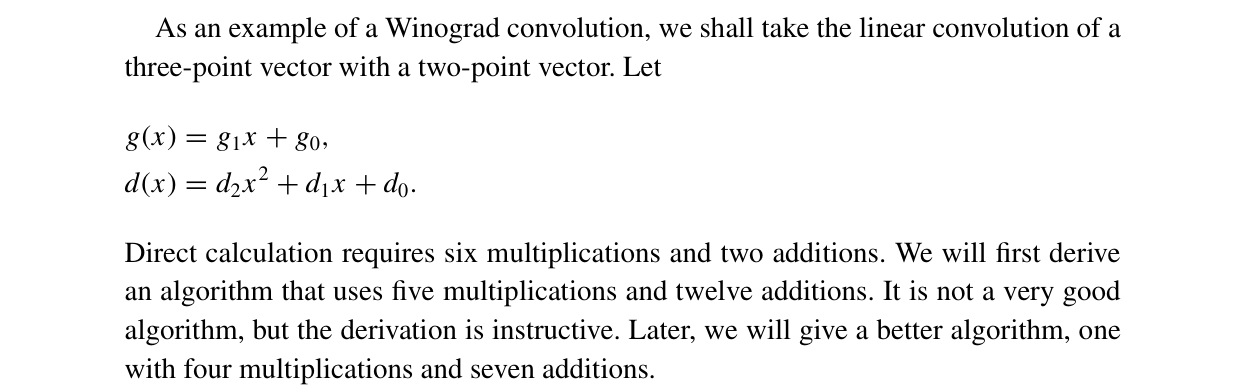

In [57]:
plot_pdf(doc[174], [.25, .455])

Size of vectors

In [261]:
d_num = 3
g_num = 3

Example of vectors for the convolution

In [262]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2, 3]


Polynomial degree

In [263]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 2


In [264]:
x = sy.symbols("x")
x

x

In [265]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1],
[d_2]])

In [266]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1],
[g_2]])

In [267]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x + d_2*x**2

In [268]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x + g_2*x**2

In [269]:
sx = gx*dx
sx

(d_0 + d_1*x + d_2*x**2)*(g_0 + g_1*x + g_2*x**2)

In [270]:
dg = sy.expand(sum(gi)*sum(di))
dg

d_0*g_0 + d_0*g_1 + d_0*g_2 + d_1*g_0 + d_1*g_1 + d_1*g_2 + d_2*g_0 + d_2*g_1 + d_2*g_2

In [271]:
out = np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1))
sy.Matrix(out)

Matrix([
[                    d_0*g_0],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[          d_1*g_2 + d_2*g_1],
[                    d_2*g_2]])

In [139]:
f = sy.Matrix([dg - i  if 0 < e < len(out)-1 else i for e, i in enumerate(out)])
f

Matrix([
[                                                            d_0*g_0],
[d_0*g_0 + d_0*g_2 + d_1*g_1 + d_1*g_2 + d_2*g_0 + d_2*g_1 + d_2*g_2],
[          d_0*g_0 + d_0*g_1 + d_1*g_0 + d_1*g_2 + d_2*g_1 + d_2*g_2],
[d_0*g_0 + d_0*g_1 + d_0*g_2 + d_1*g_0 + d_1*g_1 + d_2*g_0 + d_2*g_2],
[                                                            d_2*g_2]])

In [260]:
fm = sy.Matrix([[d.coeff(c, 1)*c for c in dg.args] for d in f])
fm.T

Matrix([
[d_0*g_0,       0,       0, 0, 0,       0,       0,       0, 0, 0,       0,       0,       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[d_0*g_0,       0, d_0*g_2, 0, 0,       0, d_1*g_1, d_1*g_2, 0, 0, d_2*g_0, d_2*g_1, d_2*g_2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[d_0*g_0, d_0*g_1,       0, 0, 0, d_1*g_0,       0, d_1*g_2, 0, 0,       0, d_2*g_1, d_2*g_2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[d_0*g_0, d_0*g_1, d_0*g_2, 0, 0, d_1*g_0, d_1*g_1,       0, 0, 0, d_2*g_0,       0, d_2*g_2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[      0,       0,       0, 0, 0,       0,       0,       0, 0, 0,       0,       0, d_2*g_2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [106]:
fm.T.rref()[0]

Matrix([
[1, 0, 0, 0, 0],
[0, 1, 0, 0, 0],
[0, 0, 1, 0, 0],
[0, 0, 0, 1, 0],
[0, 0, 0, 0, 1],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0]])

In [112]:
s1 = (gi[0] + gi[1]) * (di[0] + di[1]) - gi[0]*di[0] - gi[1]*di[1]
s1

-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1)

In [137]:
gi[0]*di[0] + gi[1]*di[1] + di[0]*gi[0] + di[1]*gi[1] - gi[0]*di[0] - gi[1]*di[1]

d_0*g_0 + d_1*g_1

In [ ]:
out[1].args[0].args

In [154]:
out[1].args[1].args

(d_1, g_0)

In [208]:
d1 = [c for c in di for d in out[1].args if d.coeff(c, 1) != 0]
d1

[d_0, d_1]

In [209]:
g1 = [c for c in gi for d in out[1].args if d.coeff(c, 1) != 0]
g1

[g_0, g_1]

In [211]:
t1 = np.prod([np.sum(i) for i in [d1, g1]])
t1

(d_0 + d_1)*(g_0 + g_1)

In [213]:
tt1 = t1.expand() - out[1]
tt1

d_0*g_0 + d_1*g_1

In [214]:
t1 - tt1

-d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1)

In [216]:
from collections import Counter

[d_0, d_1, d_2]

In [316]:
conv_idx = 3
quo, rem = np.divmod(len(out[conv_idx].args), 2)
if rem == 0:
    out2 = out[conv_idx].args
else:
    out2 = [i for e, i in enumerate(out[conv_idx].args) if sum([quo, rem])-1 != e]
out2

(d_1*g_2, d_2*g_1)

In [317]:
# max(k for k,v in Counter(mylist).items() if v>1)

idx = [e for e, c in enumerate(di) for d in out2 if d.coeff(c, 1) != 0]
idx


[1, 2]

In [319]:
t2 = np.prod([np.sum([(c[i]) for i in idx]) for c in [di, gi]])
t2

(d_1 + d_2)*(g_1 + g_2)

In [323]:
tt2 = t2.expand() - out[conv_idx]
tt2

d_1*g_1 + d_2*g_2

In [324]:
t2 - tt2

-d_1*g_1 - d_2*g_2 + (d_1 + d_2)*(g_1 + g_2)